In [12]:
# 1. SETUP & INSTALLATION
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.metrics import confusion_matrix, classification_report, r2_score, mean_squared_error, accuracy_score
from sklearn.model_selection import train_test_split

# --- CONFIGURATION ---
BASE_PATH = os.path.dirname(os.getcwd())
INPUT_FEATURES = f'{BASE_PATH}/datasets/X_features.csv'
INPUT_TARGETS = f'{BASE_PATH}/datasets/y_targets.csv'
MODEL_DIR = f'{BASE_PATH}/models'

print(f"Base Path: {BASE_PATH}")
print(f"Model Directory: {MODEL_DIR}")

Base Path: /Users/abhijitchaudhuri/Downloads/Orange_freshness_project
Model Directory: /Users/abhijitchaudhuri/Downloads/Orange_freshness_project/models


In [13]:
# 2. LOAD MODELS AND DATA
# ==========================================
print("="*60)
print("LOADING RESOURCES")
print("="*60)

# Load trained models
reg_day = joblib.load(f'{MODEL_DIR}/model_day_rf.pkl')
try:
    reg_folic = joblib.load(f'{MODEL_DIR}/model_folic_rf.pkl')
    folic_available = True
    print("✓ Folic acid model loaded")
except FileNotFoundError:
    reg_folic = None
    folic_available = False
    print("⚠️ Folic acid model not found; skipping folic validation")

scaler = joblib.load(f'{MODEL_DIR}/scaler.pkl')
selected_indices = joblib.load(f'{MODEL_DIR}/selected_features.pkl')
print("✓ Models and scaler loaded successfully")

# Load data
X = pd.read_csv(INPUT_FEATURES)
y = pd.read_csv(INPUT_TARGETS)
print(f"✓ Data loaded: {X.shape[0]} samples")

# Handle mixed batch types (same as training notebook)
y['batch_str'] = y['batch'].astype(str)

# --- Day model split (unseen batches 6-7) ---
test_mask_day = y['batch_str'].isin(['6', '7'])
X_test_day = X[test_mask_day].copy()
y_test_day = y[test_mask_day].copy()
y_quant_test = y_test_day['day']

# Apply preprocessing
X_test_day_scaled = scaler.transform(X_test_day)
X_test_day_opt = X_test_day_scaled[:, selected_indices]

# Get feature names
all_feature_names = X.columns
selected_feature_names = all_feature_names[selected_indices]

print("\n" + "="*60)
print("VALIDATION DATASET (DAY MODEL)")
print("="*60)
print(f"Test samples: {len(X_test_day)} (unseen real batches 6-7)")
print(f"Test batches: {sorted(y_test_day['batch_str'].unique())}")
print(f"Day range: {y_quant_test.min():.2f}-{y_quant_test.max():.2f}")
print(f"Selected features: {list(selected_feature_names)}")

# --- Folic acid split (batch 5 hold-out) ---
folic_ready = folic_available and ('true_conc_uM' in y.columns)
if folic_ready:
    conc_mask = y['true_conc_uM'].notna()
    conc_batches = y.loc[conc_mask, 'batch'].astype(int)
    conc_test_mask = conc_mask & (conc_batches == 5)
    conc_train_mask = conc_mask & (conc_batches <= 4)

    X_test_folic = X[conc_test_mask].copy()
    y_test_folic = y.loc[conc_test_mask, 'true_conc_uM'].copy()

    X_test_folic_scaled = scaler.transform(X_test_folic)
    X_test_folic_opt = X_test_folic_scaled[:, selected_indices]

    print("\n" + "="*60)
    print("VALIDATION DATASET (FOLIC ACID MODEL)")
    print("="*60)
    print(f"Test samples (batch 5): {len(X_test_folic)}")
    print(f"Train samples (batches ≤4): {(conc_train_mask).sum()}")
    print(f"Folic conc range (test): {y_test_folic.min():.2f}-{y_test_folic.max():.2f} µM")
else:
    print("\nFolic acid labels or model not available; skipping folic validation.")

LOADING RESOURCES
✓ Folic acid model loaded
✓ Models and scaler loaded successfully
✓ Data loaded: 2050 samples

VALIDATION DATASET (DAY MODEL)
Test samples: 415 (unseen real batches 6-7)
Test batches: ['6', '7']
Day range: 0.00-14.00
Selected features: ['Mean', 'Energy', 'DCT_1', 'DCT_2', 'DCT_3']

VALIDATION DATASET (FOLIC ACID MODEL)
Test samples (batch 5): 7
Train samples (batches ≤4): 28
Folic conc range (test): 29.59-175.00 µM



FOLIC ACID VALIDATION
Folic Acid Prediction Performance (batch 5 hold-out):
  RMSE: ±0.79 µM
  MAE: ±0.73 µM
  R² Score: 0.9997


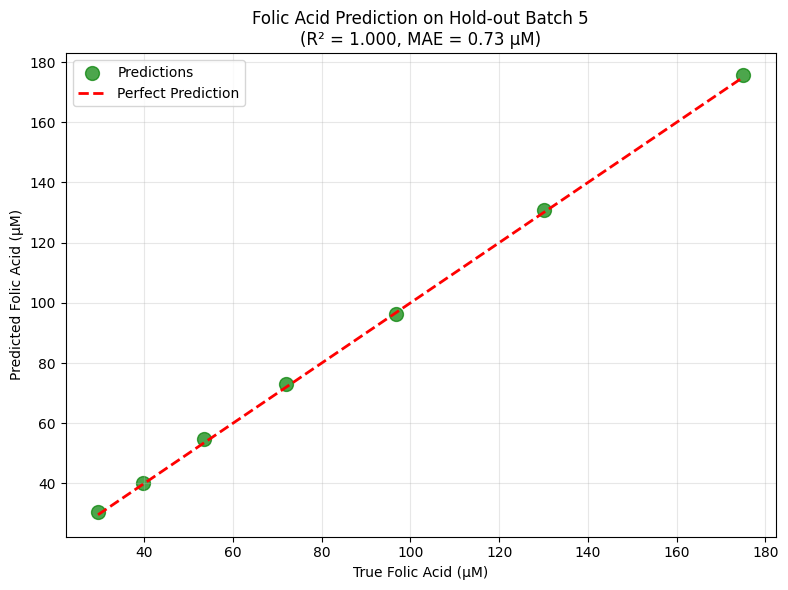

In [14]:
# 3. FOLIC ACID VALIDATION (if model and labels available)
# ==========================================
if folic_ready and reg_folic is not None and len(X_test_folic) > 0:
    print("\n" + "="*60)
    print("FOLIC ACID VALIDATION")
    print("="*60)

    y_folic_pred = reg_folic.predict(X_test_folic_opt)

    conc_rmse = np.sqrt(mean_squared_error(y_test_folic, y_folic_pred))
    conc_mae = np.mean(np.abs(y_test_folic - y_folic_pred))
    conc_r2 = r2_score(y_test_folic, y_folic_pred)

    print(f"Folic Acid Prediction Performance (batch 5 hold-out):")
    print(f"  RMSE: ±{conc_rmse:.2f} µM")
    print(f"  MAE: ±{conc_mae:.2f} µM")
    print(f"  R² Score: {conc_r2:.4f}")

    plt.figure(figsize=(8, 6))
    plt.scatter(y_test_folic, y_folic_pred, color='green', alpha=0.7, label='Predictions', s=100)
    plt.plot([y_test_folic.min(), y_test_folic.max()],
             [y_test_folic.min(), y_test_folic.max()],
             'r--', lw=2, label='Perfect Prediction')
    plt.title(f'Folic Acid Prediction on Hold-out Batch 5\n(R² = {conc_r2:.3f}, MAE = {conc_mae:.2f} µM)')
    plt.xlabel('True Folic Acid (µM)')
    plt.ylabel('Predicted Folic Acid (µM)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\nSkipping folic acid validation (model or labels missing).")


REGRESSION VALIDATION (DAY)
Storage Day Prediction Performance:
  RMSE: ±1.65 days
  MAE: ±1.14 days
  R² Score: 0.8372


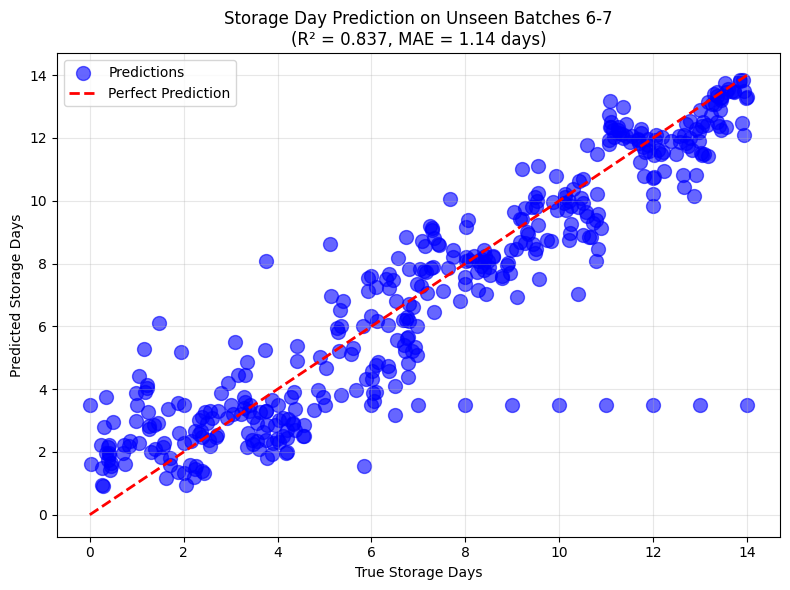


Interpretation:
- Model tested on completely unseen batches (6 & 7)
- Average prediction error: 1.1 days
- Day range in test: 0.0-14.0 days
- ✓ Excellent! Model generalizes well to new batches

Sample Predictions:
 True_Day  Predicted_Day   Error
    11.69       11.84980 0.15980
    10.50        9.91395 0.58605
     7.33        8.80270 1.47270
     6.12        6.16085 0.04085
    12.87       10.15255 2.71745
     7.17        7.72655 0.55655
     9.50        8.45050 1.04950
     1.48        6.10510 4.62510
     4.78        3.32165 1.45835
    13.35       12.50120 0.84880


In [15]:
# 4. REGRESSION REPORT (Storage Day Prediction)
# ==========================================
print("\n" + "="*60)
print("REGRESSION VALIDATION (DAY)")
print("="*60)

y_quant_pred = reg_day.predict(X_test_day_opt)

# Metrics
rmse = np.sqrt(mean_squared_error(y_quant_test, y_quant_pred))
mae = np.mean(np.abs(y_quant_test - y_quant_pred))
r2 = r2_score(y_quant_test, y_quant_pred)

print(f"Storage Day Prediction Performance:")
print(f"  RMSE: ±{rmse:.2f} days")
print(f"  MAE: ±{mae:.2f} days")
print(f"  R² Score: {r2:.4f}")

# Prediction vs Actual Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_quant_test, y_quant_pred, color='blue', alpha=0.6, label='Predictions', s=100)
plt.plot([y_quant_test.min(), y_quant_test.max()], 
         [y_quant_test.min(), y_quant_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.title(f'Storage Day Prediction on Unseen Batches 6-7\n(R² = {r2:.3f}, MAE = {mae:.2f} days)')
plt.xlabel('True Storage Days')
plt.ylabel('Predicted Storage Days')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print(f"- Model tested on completely unseen batches (6 & 7)")
print(f"- Average prediction error: {mae:.1f} days")
print(f"- Day range in test: {y_quant_test.min()}-{y_quant_test.max()} days")
if r2 > 0.7:
    print(f"- ✓ Excellent! Model generalizes well to new batches")
elif r2 > 0.5:
    print(f"- Good predictive power on unseen data")
elif r2 > 0.3:
    print(f"- Moderate performance - consider collecting more diverse training data")
else:
    print(f"- Limited generalization - needs more training samples or better features")

# Show some example predictions
print("\nSample Predictions:")
comparison = pd.DataFrame({
    'True_Day': y_quant_test.values[:10],
    'Predicted_Day': y_quant_pred[:10],
    'Error': np.abs(y_quant_test.values[:10] - y_quant_pred[:10])
})
print(comparison.to_string(index=False))


Generating SHAP Explanations (Why did the AI decide this?)...


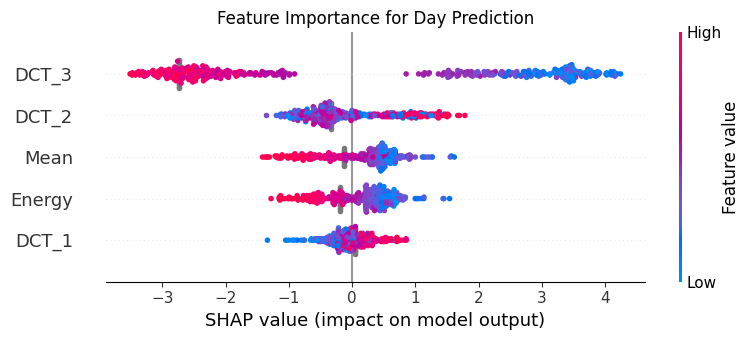

In [16]:
# 5. EXPLAINABILITY (SHAP) - Optional if shap is installed
# ==========================================
try:
    import shap
    print("\nGenerating SHAP Explanations (Why did the AI decide this?)...")
    
    # We use TreeExplainer for the Random Forest Regressor
    explainer = shap.TreeExplainer(reg_day)
    shap_values = explainer.shap_values(X_test_day_opt)
    
    # Summary Plot (The "Beeswarm" plot)
    plt.figure()
    plt.title("Feature Importance for Day Prediction")
    shap.summary_plot(shap_values, X_test_day_opt, feature_names=selected_feature_names, show=True)
except ImportError:
    print("\nSHAP not installed. Skipping explainability analysis.")
    print("To install SHAP, run: pip install shap")